In [44]:
from dotenv import load_dotenv, find_dotenv
from typing import TypedDict, Literal
from langgraph.graph import START, END, StateGraph
from openai import OpenAI
import json
from groq import Groq
from pydantic import BaseModel, Field

In [2]:
load_dotenv(find_dotenv())

True

In [18]:
class InputAnalyser(TypedDict):
    user_input: str
    analyse_output: str
    platforms: Literal['youtube', 'social_media', 'blog_posts', 'news_articles']

In [29]:
class PlatformRequired(BaseModel):
    analysis: str
    platform_needed: list[Literal['youtube', 'social_media', 'blog_posts', 'news_articles']] = Field(..., description="The values with which the the information can be extracted")

In [30]:
groq_client = Groq()

In [31]:
for model in groq_client.models.list().data:
    print(f"Model name: {model.id}")

Model name: llama-3.3-70b-versatile
Model name: openai/gpt-oss-safeguard-20b
Model name: openai/gpt-oss-20b
Model name: llama-3.1-8b-instant
Model name: canopylabs/orpheus-v1-english
Model name: moonshotai/kimi-k2-instruct
Model name: meta-llama/llama-guard-4-12b
Model name: meta-llama/llama-prompt-guard-2-86m
Model name: openai/gpt-oss-120b
Model name: meta-llama/llama-prompt-guard-2-22m
Model name: qwen/qwen3-32b
Model name: meta-llama/llama-4-maverick-17b-128e-instruct
Model name: allam-2-7b
Model name: whisper-large-v3-turbo
Model name: whisper-large-v3
Model name: groq/compound-mini
Model name: canopylabs/orpheus-arabic-saudi
Model name: moonshotai/kimi-k2-instruct-0905
Model name: groq/compound
Model name: meta-llama/llama-4-scout-17b-16e-instruct


In [37]:
SYSTEM_PROMPT = """
Role: You are a powerful and intelligent examiner. 

Task: You will be given an input in the form of string and you will then analyse the input and provide your analysis about what the user is asking. 
After that you have to tell, from which platform the information can be extracted which can information about the user query.

There can be multiple platform from which the information can be extracted e.g blog sites, youtube videos.

You have below list of platform:
1. Youtube
2. Blog Post platform like Medium, Dev.to
3. Social media platform like Linkedin, X.com
4. News Article platform like Dainik Jagran (jagran.com), New York Times (nytimes.com)

Output: I need the final output which have 2 values:
1. Analysis: Your analysis about the user input query and why you have choose that or these platforms.
2. Platform Required: which can be single platform or a list of platform using which, information can be provided to the user
"""

In [ ]:
def model_completion(system_prompt: str, user_prompt: str) -> str | None:

    chat_completion = groq_client.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": system_prompt
            },
            {
                "role": "user",
                "content": user_prompt
            }
        ],
        model="meta-llama/llama-4-maverick-17b-128e-instruct",
        temperature=0,
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "PlatformRequired",
                "schema": PlatformRequired.model_json_schema()
            }
        }
    )

    return chat_completion.choices[0].message.content

In [43]:
print(model_completion(system_prompt=SYSTEM_PROMPT, user_prompt=USER_PROMPT))

{
"analysis": "The user is asking for the latest AI trend that happened in the last month, indicating they are looking for recent developments or updates in the field of Artificial Intelligence. This suggests they are likely interested in news or updates that have been published recently. Given the timeframe (last month), the information is likely to be found on platforms that regularly publish updates, news, or in-depth analyses.",
  "platform_needed": ["news_articles", "blog_posts", "social_media"]
}


In [45]:
def analyse_input(state: InputAnalyser):
    user_input = state['user_input']

    model_response = json.loads(model_completion(system_prompt=SYSTEM_PROMPT, user_prompt=user_input)) # type: ignore

    if user_input:
        return {'analyse_output': model_response['analysis'], 'platforms': model_response['platform_needed']}
    else:
        return {'analyse_output': "", 'platforms': None}

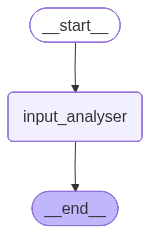

In [46]:
builder = StateGraph(InputAnalyser)
builder.add_node("input_analyser", analyse_input)
builder.add_edge(START, "input_analyser")
builder.add_edge("input_analyser", END)

graph = builder.compile()

graph

In [48]:
graph.invoke({"user_input": "what is the latest update happening between India and Pakistan related to cricket"}) # type: ignore

{'user_input': 'what is the latest update happening between India and Pakistan related to cricket',
 'analyse_output': 'The user is asking about the latest update between India and Pakistan related to cricket. This suggests that the user is looking for recent news or developments in the cricketing relationship between the two countries. The information required is likely to be found in recent news articles or social media updates.',
 'platforms': ['news_articles', 'social_media']}